# TASK 7: SMOOTH SWITCHING HYBRID SYSTEM

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from smooth_hybrid_recommender import SmoothHybridRecommender, visualize_weight_curves

print("TASK 7: SMOOTH SWITCHING HYBRID SYSTEM")

TASK 7: SMOOTH SWITCHING HYBRID SYSTEM


## SMOOTH WEIGHTING FUNCTIONS


SMOOTH WEIGHTING FUNCTIONS
Đã lưu: ../figures/weight_curves.png


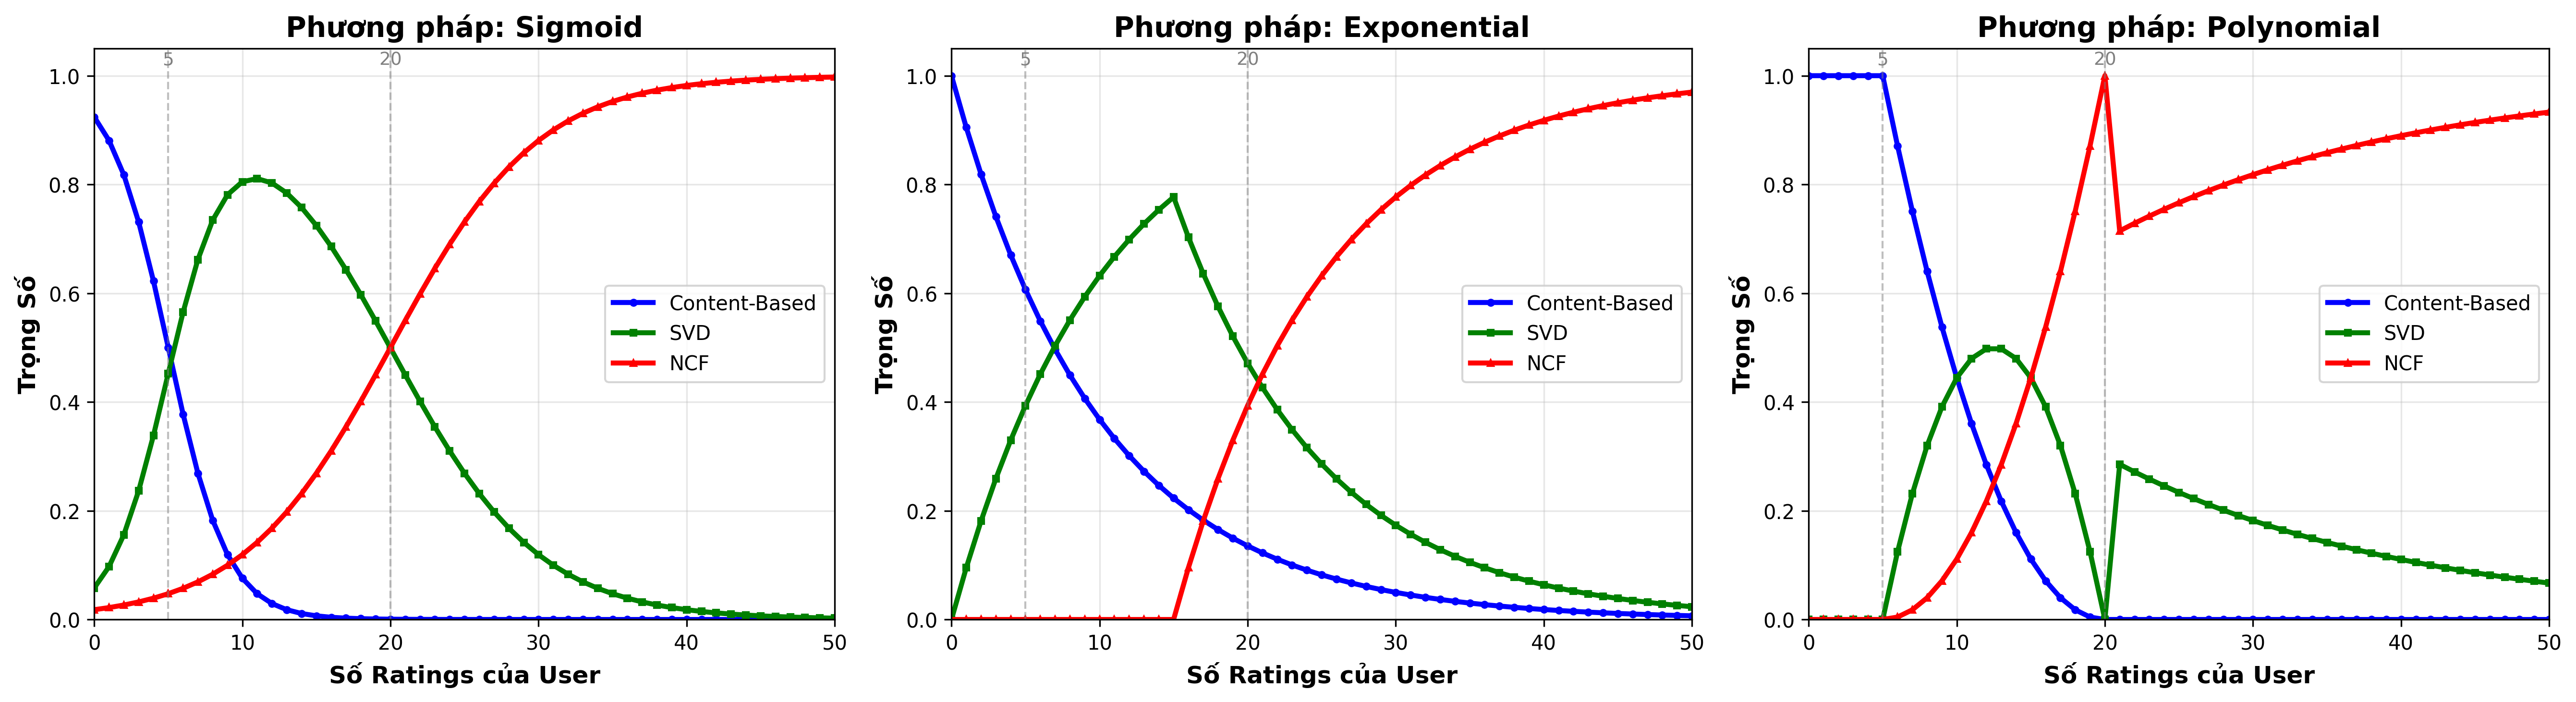

In [2]:
print("\nSMOOTH WEIGHTING FUNCTIONS")

visualize_weight_curves('../figures/weight_curves.png')

# Display the plot
from IPython.display import Image
Image('../figures/weight_curves.png')

## BUILD SMOOTH HYBRID RECOMMENDER

In [3]:
print("\nBUILD SMOOTH HYBRID RECOMMENDER")

hybrid = SmoothHybridRecommender.load()
print(hybrid)


BUILD SMOOTH HYBRID RECOMMENDER
ĐANG TẢI HỆ THỐNG HYBRID RECOMMENDER
Đang tải Content-Based...
Đã load Content-Based Model thành công!
  - Số phim: 3,416
  - Top-K: 100
  - Matrix shape: (3416, 100)
Đang tải SVD...
Project root: D:\workspace\MovieRecommender_1M
Model dir: D:\workspace\MovieRecommender_1M\models
Data dir: D:\workspace\MovieRecommender_1M\data\cleaned
Đã load model: svd_model.pkl
Đã load dữ liệu: 3,416 phim, 1,000,209 đánh giá
Đã cache 6040 users, 3682 phim
Đang tính toán ma trận fold-in...
Đã tính toán ma trận fold-in (50x50)
Hệ thống sẵn sàng với LRU cache 1000
Đang tải NCF...
Đang khởi tạo NCF Recommender...
Đang load model từ ..\models\neural_cf_model.h5...
Đang load encoders...
Đang load dữ liệu...
Đã load 1,000,209 ratings và 3,416 movies
Đang xây dựng user-movie cache...
Đã cache 6,040 users
NCF Recommender sẵn sàng!
   - Số users: 6,040
   - Số movies: 3,416
   - Số ratings: 1,000,209
   - Cache đã được khởi tạo
Đang tải dữ liệu...
Hoàn tất!
Smooth Hybrid Recomm

## TEST SMOOTH HYBRID SYSTEM

In [4]:
print("\nTEST SMOOTH HYBRID SYSTEM")

test_users = [
    (0, "New user - Cold start"),
    (3, "Very light user"),
    (7, "Light user"), 
    (15, "Moderate user"),
    (25, "Active user"),
    (50, "Very active user")
]

results_list = []

for n_ratings, desc in test_users:
    # Find a user with approximately n_ratings
    user_counts = hybrid.ratings.groupby('userId').size()
    
    if n_ratings == 0:
        # Test cold start
        
        print(f"TEST: {desc} (n_ratings={n_ratings})")
        favorite_movies = [(1, 5), (260, 4), (1196, 5)]
        recs = hybrid.recommend_for_new_user(favorite_movies, n=5)
        
        print("\nTop 5 Recommendations:")
        if not recs.empty:
            for _, row in recs.iterrows():
                print(f"#{row['rank']} {row['title_clean'][:35]:<35} → {row['predicted_rating']:.2f}")
        
        weights = {'content': 1.0, 'svd': 0.0, 'ncf': 0.0}
    else:
        # Find user with similar rating count
        target_users = user_counts[(user_counts >= n_ratings - 2) & 
                                   (user_counts <= n_ratings + 2)]
        
        if len(target_users) > 0:
            user_id = target_users.index[0]
            actual_count = user_counts[user_id]
            
            
            print(f"TEST: {desc} (User {user_id}, n_ratings={actual_count})")
            
            
            recs, weights = hybrid.recommend(
                user_id, n=5, method='sigmoid',
                return_weights=True, verbose=True
            )
            
            print("\nTop 5 Recommendations:")
            if not recs.empty:
                for _, row in recs.iterrows():
                    print(f"#{row['rank']} {row['title_clean'][:35]:<35} → {row['predicted_rating']:.2f}")
            
            results_list.append({
                'n_ratings': actual_count,
                'content_weight': weights['content'],
                'svd_weight': weights['svd'],
                'ncf_weight': weights['ncf']
            })

# Verify smooth transition
if results_list:
    results_df = pd.DataFrame(results_list).sort_values('n_ratings')
   
    print("WEIGHT TRANSITION TABLE")
    print(results_df.to_string(index=False))


TEST SMOOTH HYBRID SYSTEM
TEST: New user - Cold start (n_ratings=0)
GỢI Ý CHO NGƯỜI DÙNG MỚI
Phim yêu thích: 3
Trọng số: CB=0.73, SVD=0.24, NCF=0.03
Tìm được 10 phim từ movie 1
Tìm được 10 phim từ movie 260
Tìm được 10 phim từ movie 1196

Top 5 Recommendations:
#1 Toy Story 2                         → 5.00
#2 Star Wars: Episode I - The Phantom  → 3.35
#3 Star Wars: Episode VI - Return of t → 3.12
#4 Tron                                → 2.69
#5 Star Kid                            → 2.21
TEST: Active user (User 12, n_ratings=23)
GỢI Ý HYBRID - User 12
Số đánh giá: 23
Trọng số:
   - Content-Based: 0.000
   - SVD: 0.354
   - NCF: 0.646

Top 5 Recommendations:
#1 Shawshank Redemption, The           → 4.33
#2 Sanjuro                             → 4.32
#3 Seven Samurai (The Magnificent Seve → 4.30
#4 Rear Window                         → 4.29
#5 Usual Suspects, The                 → 4.25
TEST: Very active user (User 3, n_ratings=51)
GỢI Ý HYBRID - User 3
Số đánh giá: 51
Trọng số:
   - Conte

## COMPARE SMOOTH VS HARD SWITCHING

In [5]:
print("\nCOMPARE SMOOTH VS HARD SWITCHING")

# Select test users
user_counts = hybrid.ratings.groupby('userId').size()
test_user_ids = []

for target_n in [4, 5, 6, 10, 15, 20, 25, 30]:
    candidates = user_counts[(user_counts >= target_n - 1) & 
                             (user_counts <= target_n + 1)]
    if len(candidates) > 0:
        test_user_ids.append(candidates.index[0])

comparison_df = hybrid.compare_smooth_vs_hard(test_user_ids[:10], n=10)

print("\nSmooth vs Hard Weights Comparison:")
print(comparison_df[['user_id', 'n_ratings', 
                      'smooth_cb', 'smooth_svd', 'smooth_ncf',
                      'hard_cb', 'hard_svd', 'hard_ncf']].to_string(index=False))

# Save comparison
comparison_df.to_csv('../models/comparison_smooth_vs_hard.csv', index=False)
print("\nĐã lưu: models/comparison_smooth_vs_hard.csv")


COMPARE SMOOTH VS HARD SWITCHING

Smooth vs Hard Weights Comparison:
 user_id  n_ratings  smooth_cb  smooth_svd  smooth_ncf  hard_cb  hard_svd  hard_ncf
       4         21   0.000335    0.449831    0.549834      0.0       0.0       1.0
      14         25   0.000045    0.268896    0.731059      0.0       0.0       1.0
       7         31   0.000002    0.099748    0.900250      0.0       0.0       1.0

Đã lưu: models/comparison_smooth_vs_hard.csv


## VISUALIZE SMOOTH VS HARD


VISUALIZE SMOOTH VS HARD
Đã lưu: figures/smooth_vs_hard_comparison.png


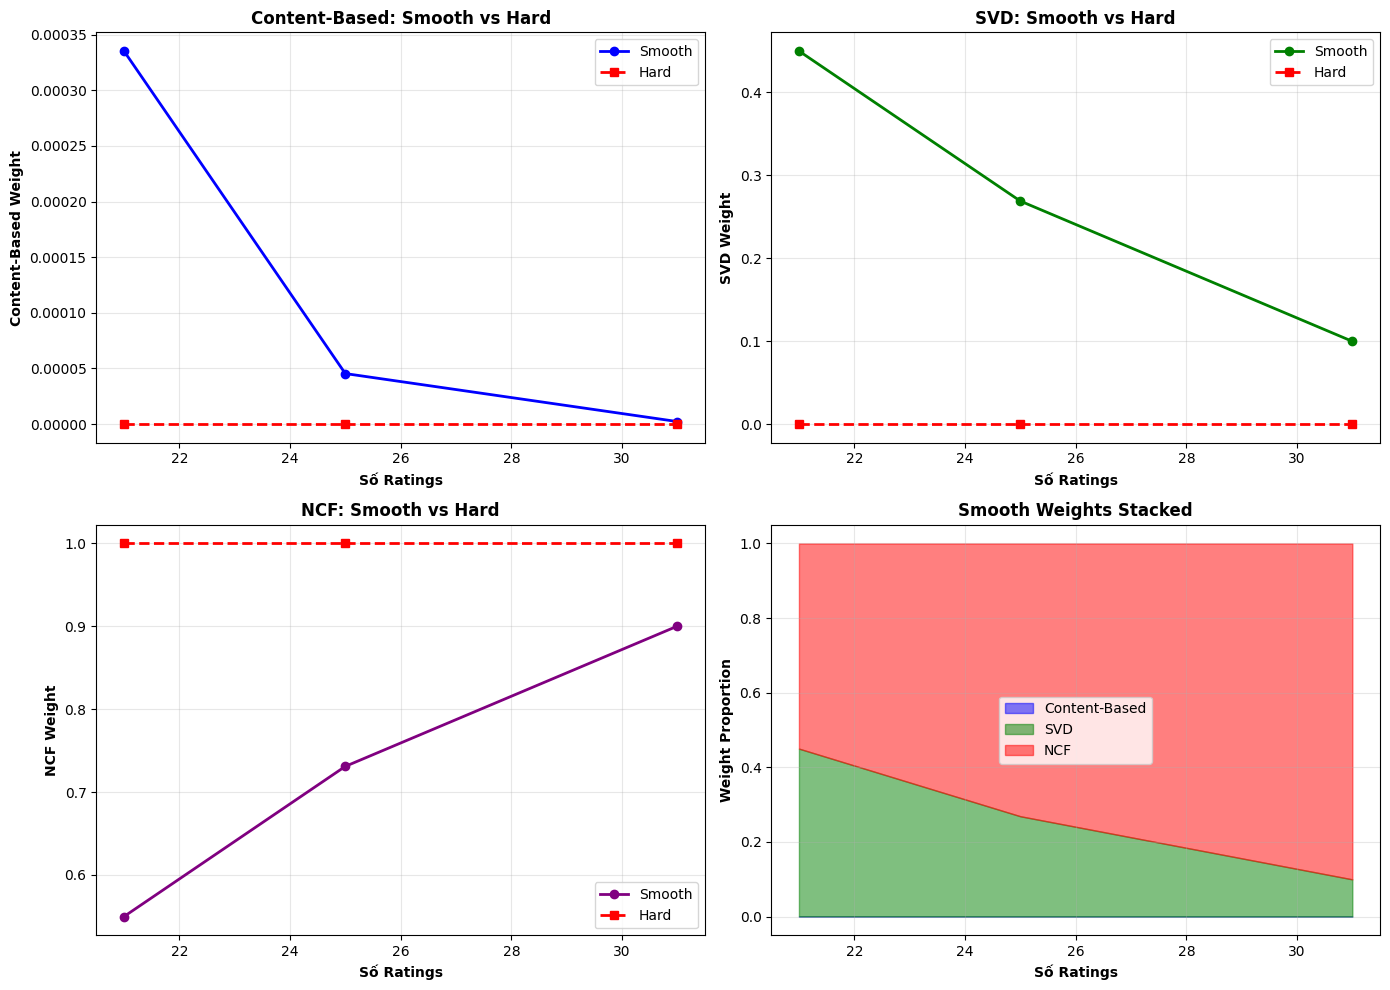

In [6]:
print("\nVISUALIZE SMOOTH VS HARD")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Content-Based weights
axes[0, 0].plot(comparison_df['n_ratings'], comparison_df['smooth_cb'], 
                'b-o', linewidth=2, label='Smooth', markersize=6)
axes[0, 0].plot(comparison_df['n_ratings'], comparison_df['hard_cb'],
                'r--s', linewidth=2, label='Hard', markersize=6)
axes[0, 0].set_xlabel('Số Ratings', fontweight='bold')
axes[0, 0].set_ylabel('Content-Based Weight', fontweight='bold')
axes[0, 0].set_title('Content-Based: Smooth vs Hard', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: SVD weights
axes[0, 1].plot(comparison_df['n_ratings'], comparison_df['smooth_svd'],
                'g-o', linewidth=2, label='Smooth', markersize=6)
axes[0, 1].plot(comparison_df['n_ratings'], comparison_df['hard_svd'],
                'r--s', linewidth=2, label='Hard', markersize=6)
axes[0, 1].set_xlabel('Số Ratings', fontweight='bold')
axes[0, 1].set_ylabel('SVD Weight', fontweight='bold')
axes[0, 1].set_title('SVD: Smooth vs Hard', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: NCF weights
axes[1, 0].plot(comparison_df['n_ratings'], comparison_df['smooth_ncf'],
                'purple', marker='o', linewidth=2, label='Smooth', markersize=6)
axes[1, 0].plot(comparison_df['n_ratings'], comparison_df['hard_ncf'],
                'r--s', linewidth=2, label='Hard', markersize=6)
axes[1, 0].set_xlabel('Số Ratings', fontweight='bold')
axes[1, 0].set_ylabel('NCF Weight', fontweight='bold')
axes[1, 0].set_title('NCF: Smooth vs Hard', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: All weights stacked
axes[1, 1].fill_between(comparison_df['n_ratings'], 0, comparison_df['smooth_cb'],
                         alpha=0.5, label='Content-Based', color='blue')
axes[1, 1].fill_between(comparison_df['n_ratings'], 
                         comparison_df['smooth_cb'],
                         comparison_df['smooth_cb'] + comparison_df['smooth_svd'],
                         alpha=0.5, label='SVD', color='green')
axes[1, 1].fill_between(comparison_df['n_ratings'],
                         comparison_df['smooth_cb'] + comparison_df['smooth_svd'],
                         1.0, alpha=0.5, label='NCF', color='red')
axes[1, 1].set_xlabel('Số Ratings', fontweight='bold')
axes[1, 1].set_ylabel('Weight Proportion', fontweight='bold')
axes[1, 1].set_title('Smooth Weights Stacked', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/smooth_vs_hard_comparison.png', dpi=300, bbox_inches='tight')
print("Đã lưu: figures/smooth_vs_hard_comparison.png")
plt.show()

## Summary

In [7]:
print("TASK 7 HOÀN TẤT!")


print("\nChecklist:")
print("Implement Smooth Weighting Functions (sigmoid, exponential, polynomial)")
print("Build Smooth Hybrid Recommender Class")
print("Compare Smooth vs Hard Switching")
print("Handle Cold Start")
print("Test với users có số ratings khác nhau")

print("\nOutput Files:")
print("   - src/smooth_hybrid_recommender.py")
print("   - notebooks/07_smooth_hybrid_system.ipynb")
print("   - figures/weight_curves.png")
print("   - figures/smooth_vs_hard_comparison.png")
print("   - models/comparison_smooth_vs_hard.csv")

print("\nKey Features:")
print("   - 3 smooth transition methods: sigmoid, exponential, polynomial")
print("   - No discontinuity in weights")
print("   - Cold start handling cho new users")
print("   - Weighted average recommendations")
print("   - Comparison smooth vs hard switching")

TASK 7 HOÀN TẤT!

Checklist:
Implement Smooth Weighting Functions (sigmoid, exponential, polynomial)
Build Smooth Hybrid Recommender Class
Compare Smooth vs Hard Switching
Handle Cold Start
Test với users có số ratings khác nhau

Output Files:
   - src/smooth_hybrid_recommender.py
   - notebooks/07_smooth_hybrid_system.ipynb
   - figures/weight_curves.png
   - figures/smooth_vs_hard_comparison.png
   - models/comparison_smooth_vs_hard.csv

Key Features:
   - 3 smooth transition methods: sigmoid, exponential, polynomial
   - No discontinuity in weights
   - Cold start handling cho new users
   - Weighted average recommendations
   - Comparison smooth vs hard switching
